# Codveda Internship — Level 2 (Intermediate)

Covers:
- Task 1: Regression Analysis (dataset: `4) house Prediction Data Set.csv`)
- Task 2: Time Series Analysis (dataset: `2) Stock Prices Data Set.csv`)
- Task 3: Clustering Analysis - K-Means (dataset: `1) iris.csv`)

**Kaggle setup:** path below already confirmed working (`smminhajchowdhury/data-set-for-task`).

In [1]:
import os

# 1. See what's inside /kaggle/input/
print("Top-level folders in /kaggle/input/:")
print(os.listdir("/kaggle/input/"))

# 2. Walk into each folder to see the actual file names/paths
for root, dirs, files in os.walk("/kaggle/input/"):
    for f in files:
        print(os.path.join(root, f))



Top-level folders in /kaggle/input/:
['datasets']
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/2) Stock Prices Data Set.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/1) iris.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/4) house Prediction Data Set.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/3) Sentiment dataset.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = "/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "."   # fallback for local run
print(os.listdir(DATA_DIR))

['2) Stock Prices Data Set.csv', 'Churn Prdiction Data', '1) iris.csv', '4) house Prediction Data Set.csv', '3) Sentiment dataset.csv']


## Task 1: Regression Analysis
The house price file has **no header row** (classic Boston Housing style columns).
We add the standard column names below. Target = `MEDV` (median home value).

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

house_path = os.path.join(DATA_DIR, "4) house Prediction Data Set.csv")
columns = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX",
           "PTRATIO","B","LSTAT","MEDV"]

house_df = pd.read_csv(house_path, header=None, names=columns, sep=r"\s+")
house_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# Split into train/test
X = house_df.drop(columns=["MEDV"])
y = house_df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print("R-squared:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R-squared: 0.6687594935356338
MSE: 24.291119474973385


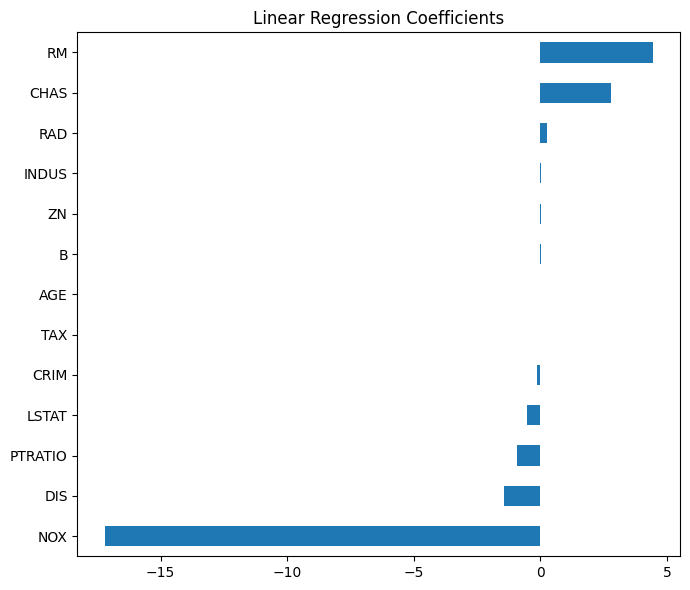

NOX       -17.202633
DIS        -1.447865
PTRATIO    -0.915456
LSTAT      -0.508571
CRIM       -0.113056
TAX        -0.010647
AGE        -0.006296
B           0.012351
ZN          0.030110
INDUS       0.040381
RAD         0.262430
CHAS        2.784438
RM          4.438835
dtype: float64

In [5]:
# Interpret coefficients
coeffs = pd.Series(lin_reg.coef_, index=X.columns).sort_values()
coeffs.plot(kind='barh', figsize=(7,6), title="Linear Regression Coefficients")
plt.tight_layout()
plt.savefig("regression_coefficients.png")
plt.show()
coeffs

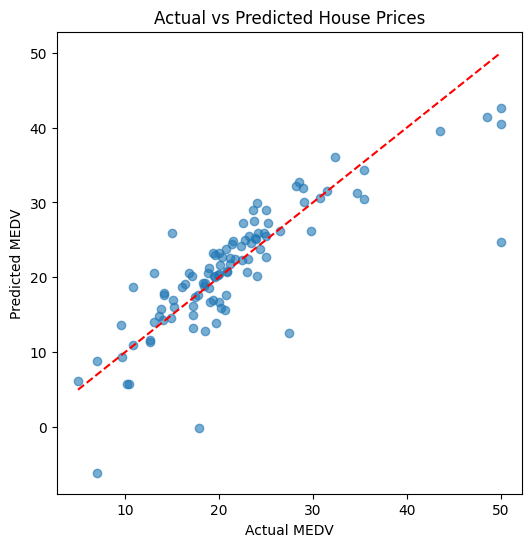

In [6]:
# Predicted vs Actual plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")
plt.savefig("regression_actual_vs_pred.png")
plt.show()

## Task 2: Time Series Analysis
The stock file has many symbols. We pick one (e.g. `AAPL`) and analyze it as a time series.

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

stock_path = os.path.join(DATA_DIR, "2) Stock Prices Data Set.csv")
stock_df = pd.read_csv(stock_path, parse_dates=["date"])

SYMBOL = "AAPL"
ts = stock_df[stock_df["symbol"] == SYMBOL].sort_values("date").set_index("date")["close"]
ts = ts.asfreq("B")          # business-day frequency
ts = ts.ffill()              # fill small gaps (e.g., holidays)
ts.head()

date
2014-01-02    79.0185
2014-01-03    77.2828
2014-01-06    77.7042
2014-01-07    77.1481
2014-01-08    77.6371
Freq: B, Name: close, dtype: float64

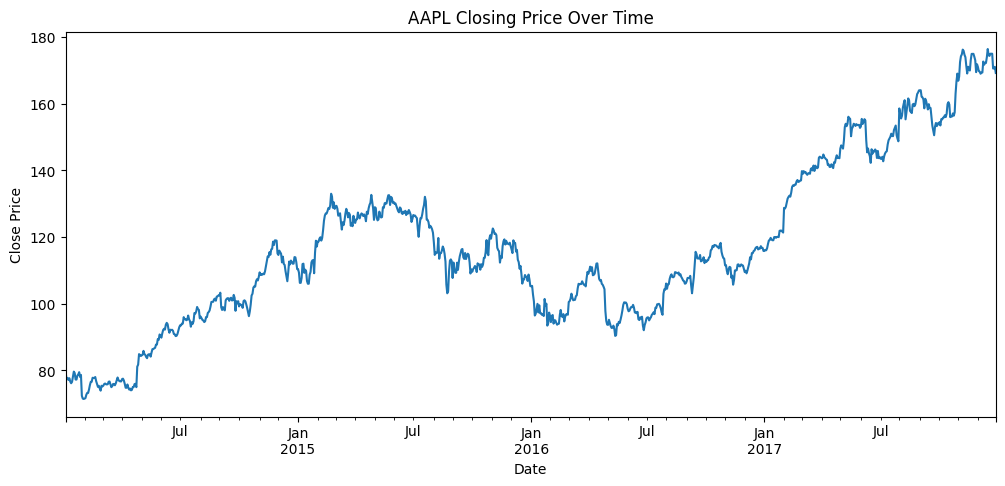

In [8]:
# Plot the raw time series
plt.figure(figsize=(12,5))
ts.plot()
plt.title(f"{SYMBOL} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.savefig("stock_raw_timeseries.png")
plt.show()

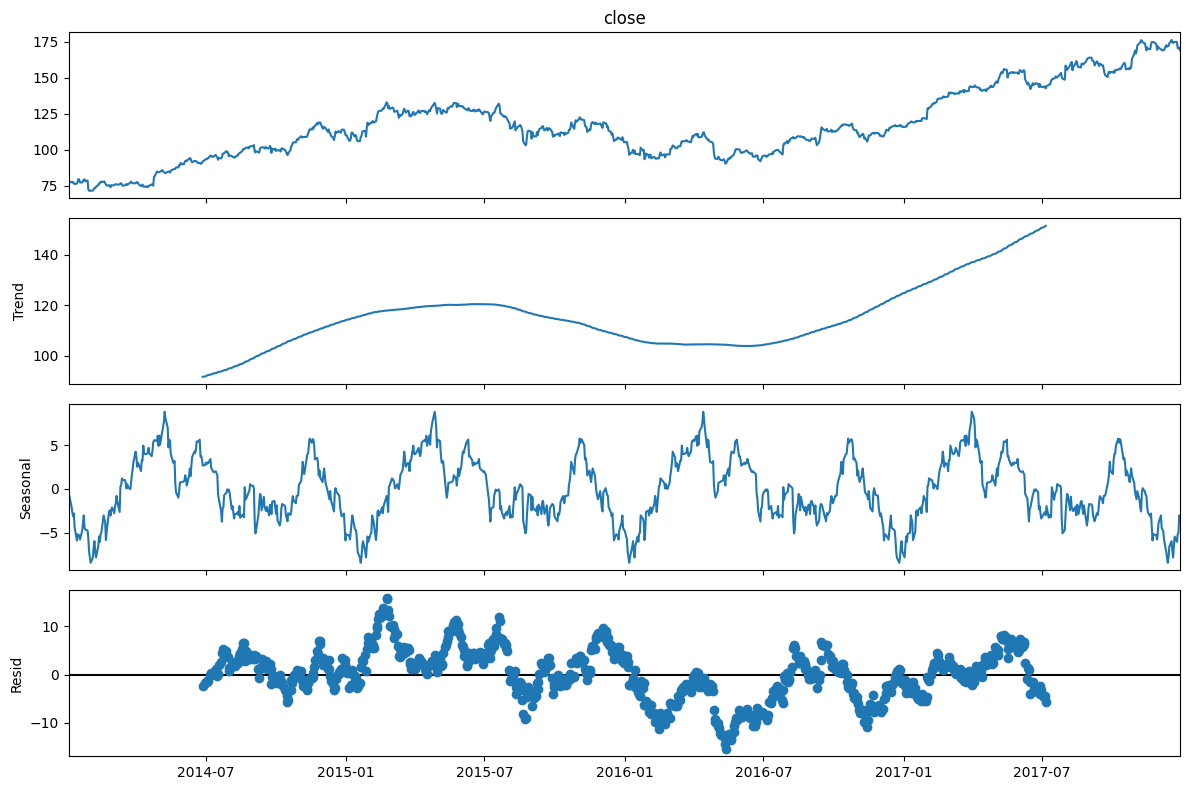

In [9]:
# Decompose into trend, seasonality, residuals
decomposition = seasonal_decompose(ts, model='additive', period=252)  # ~252 trading days/year

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("stock_decomposition.png")
plt.show()

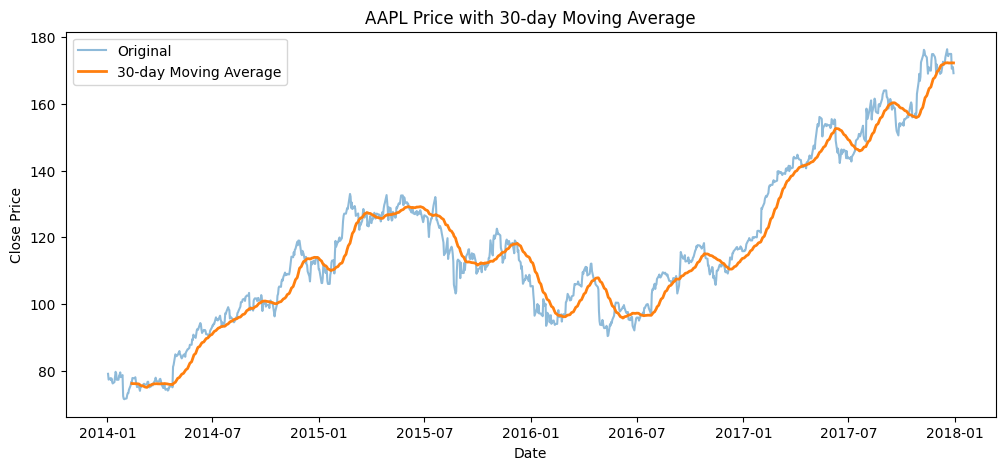

In [10]:
# Moving average smoothing
ts_ma = ts.rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(ts, label="Original", alpha=0.5)
plt.plot(ts_ma, label="30-day Moving Average", linewidth=2)
plt.title(f"{SYMBOL} Price with 30-day Moving Average")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.savefig("stock_moving_average.png")
plt.show()

## Task 3: Clustering Analysis (K-Means)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

iris_path = os.path.join(DATA_DIR, "1) iris.csv")
iris_df = pd.read_csv(iris_path)

features = iris_df.drop(columns=["species"])

# Standardize
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

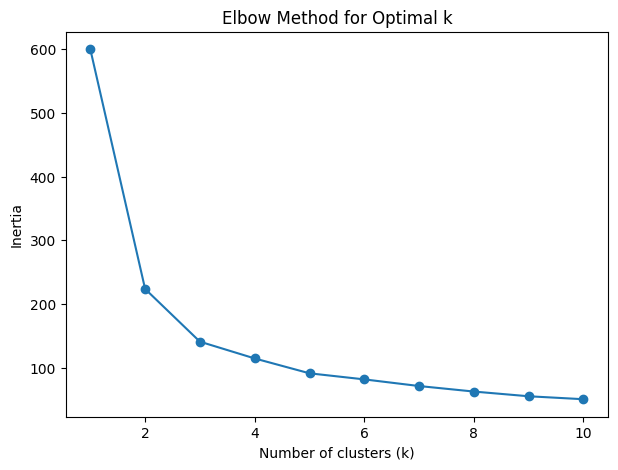

In [12]:
# Elbow method to find optimal k
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.savefig("kmeans_elbow.png")
plt.show()

In [13]:
# Fit K-Means with chosen k (3, matching the known 3 species)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

iris_df["cluster"] = clusters
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


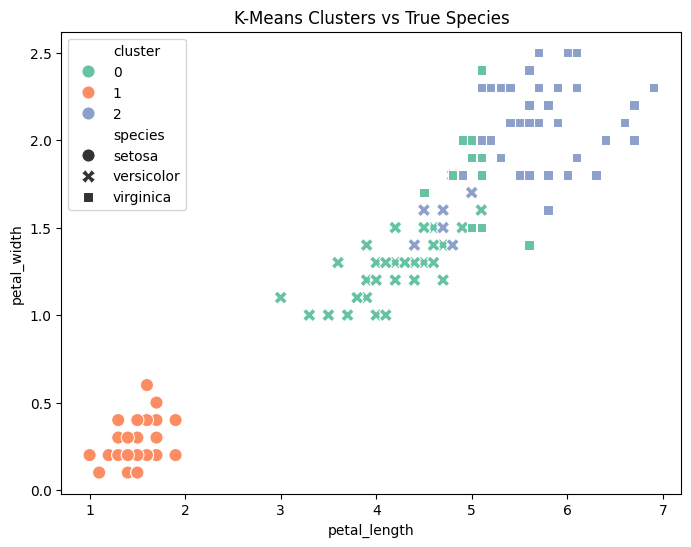

In [14]:
# Visualize clusters (2D scatter using two features)
plt.figure(figsize=(8,6))
sns.scatterplot(data=iris_df, x="petal_length", y="petal_width",
                 hue="cluster", palette="Set2", style="species", s=90)
plt.title("K-Means Clusters vs True Species")
plt.savefig("kmeans_clusters.png")
plt.show()